   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   --- ------------------------------------ 3.4/39.5 MB 16.8 MB/s eta 0:00:03
   ------ --------------------------------- 6.8/39.5 MB 16.8 MB/s eta 0:00:02
   ---------- ----------------------------- 10.0/39.5 MB 15.9 MB/s eta 0:00:02
   ------------- -------------------------- 13.4/39.5 MB 16.1 MB/s eta 0:00:02
   ---------------- ----------------------- 16.8/39.5 MB 16.3 MB/s eta 0:00:02
   -------------------- ------------------- 20.4/39.5 MB 16.4 MB/s eta 0:00:02
   ------------------------ --------------- 23.9/39.5 MB 16.4 MB/s eta 0:00:01
   --------------------------- ------------ 27.3/39.5 MB 16.5 MB/s eta 0:00:01
   ------------------------------- -------- 30.7/39.5 MB 16.5 MB/s eta 0:00:01
   ---------------------------------- ----- 34.1/39.5 MB 16.5 MB/s eta 0:00:01
   ------------------------------------- -- 37.5/39.5 MB 16.5 MB/s eta 0:00:01
   ---------------------------------------- 39.5/39.5 MB 16.0 M

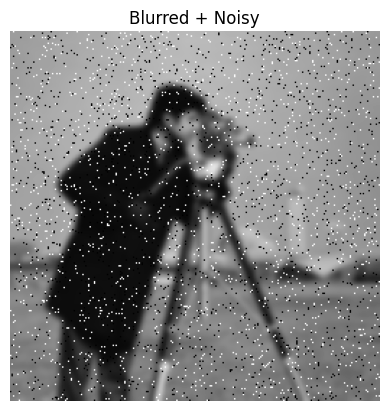

In [2]:
!pip install opencv-python
import cv2
import numpy as np
from scipy.ndimage import gaussian_filter
from skimage.util import random_noise
import matplotlib.pyplot as plt

# 读取图像（灰度）
img = cv2.imread("cameraman.jpg", cv2.IMREAD_GRAYSCALE)
img = img.astype(np.float32) / 255.0  # 归一化到 [0, 1]

# 加高斯模糊
blurred = gaussian_filter(img, sigma=2)

# 加椒盐噪声
noisy = random_noise(blurred, mode='s&p', amount=0.05)

# 显示退化图像
plt.imshow(noisy, cmap='gray')
plt.title("Blurred + Noisy")
plt.axis('off')
plt.show()


In [5]:
def chambolle_pock(b, max_iter=300, tau=0.1, sigma=0.1, theta=1.0, lmbd=0.2):
    u = b.copy()
    u_bar = u.copy()

    # 初始化梯度方向变量（注意维度）
    p1 = np.zeros_like(u[:, :-1])   # x 方向（宽 - 1）
    p2 = np.zeros_like(u[:-1, :])   # y 方向（高 - 1）

    for _ in range(max_iter):
        # 计算梯度
        grad_x = u_bar[:, 1:] - u_bar[:, :-1]
        grad_y = u_bar[1:, :] - u_bar[:-1, :]

        # Dual 更新
        p1 += sigma * grad_x
        p2 += sigma * grad_y

        # 修正维度差异，并归一化
        h = min(p1.shape[0], p2.shape[0])
        w = min(p1.shape[1], p2.shape[1])
        norm = np.maximum(1, np.sqrt(p1[:h, :w]**2 + p2[:h, :w]**2))
        p1[:h, :w] /= norm
        p2[:h, :w] /= norm

        # 散度 (divergence)
        div_p = np.zeros_like(u)
        div_p[:, :-1] += p1
        div_p[:, 1:] -= p1
        div_p[:-1, :] += p2
        div_p[1:, :] -= p2

        # Primal 更新
        u_old = u.copy()
        u = (u + tau * (div_p + b)) / (1 + tau)

        # Over-relaxation
        u_bar = u + theta * (u - u_old)

    return np.clip(u, 0, 1)

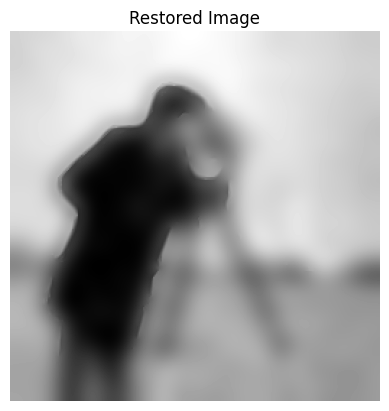

In [6]:
restored = chambolle_pock(noisy)

plt.imshow(restored, cmap='gray')
plt.title("Restored Image")
plt.axis('off')
plt.show()


In [7]:
from algorithm.abstract_deblur_algorithm import AbstractDeblurAlgorithm
import numpy as np
from utils.constants import *
from scipy.signal import convolve2d

class DeblurAlgorithmChambollePock(AbstractDeblurAlgorithm):
    def run_algorithm(self, **kwargs):
        b = kwargs.get("b")  # Blurred image
        k = kwargs.get("kernel")  # Blur kernel
        max_iter = kwargs.get("max_iter", 300)
        t = kwargs.get("tau", 0.1)  # step size t
        s = kwargs.get("sigma", 0.1)  # step size s
        lmbd = kwargs.get("lmbd", 0.2)  # regularization param

        # Define convolution operators
        def A(x):
            return convolve2d(x, k, mode='same', boundary='wrap')

        def At(x):
            return convolve2d(x, np.flip(np.flip(k, axis=0), axis=1), mode='same', boundary='wrap')

        # Initialize
        x = np.copy(b)
        y = np.zeros_like(b)
        z = np.copy(x)

        # Proximal operator for data fidelity (quadratic): prox_tf(x) = (x + t*b)/(1 + t)
        def prox_tf(x):
            return (x + t * b) / (1 + t)

        # Proximal operator for dual of TV (soft-thresholding)
        def prox_g_conj(y):
            return y / np.maximum(1.0, np.abs(y) / lmbd)

        for _ in range(max_iter):
            y = prox_g_conj(y + s * A(z))
            x_new = prox_tf(x - t * At(y))
            z = 2 * x_new - x
            x = x_new

        return np.clip(x, 0, 1)

    def should_use(self, algorithm: str) -> bool:
        return algorithm == ALGORITHM_CHAMBOLLE_POCK


In [9]:
from algorithm.deblur_algorithm_factory import get_algorithm

# 获取算法类
algo = get_algorithm(cfg.algorithm.name, cfg)

# 运行图像去模糊算法
restored = algo.run_algorithm(b=blurred_noisy_image, kernel=your_blur_kernel)


ImportError: cannot import name 'get_algorithm' from 'algorithm.deblur_algorithm_factory' (D:\pycharmproject\pythonProject\math563\ImageDeblur-reference\algorithm\deblur_algorithm_factory.py)